In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
#set random seed for reproducabillity 
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
#data prepration

#Normalization for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))

])

In [10]:
#Load datset
print("Downloading MNISt dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

tarin_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [73]:
#Baseline Model
class RichBoyNet(nn.Module):
    def __init__(self, hidden_size1=1000, hidden_size2=500, num_classes=10):
        super(RichBoyNet, self).__init__()
    

    #lareg expensive layers 
        self.linear1 = nn.Linear(28*28, hidden_size1)
        self.linear2 = nn.Linear(hidden_size1, hidden_size2)
        self.linear3 = nn.Linear(hidden_size2, 20)
        self.relu = nn.ReLU()
    def forward (self, imgs):
        x = imgs.view(-1, 28*28)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        return x
model = RichBoyNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
       

In [26]:
#Training function 
def train(model, loader, epochs=1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()))

    model.train()
    for epoch in range(epochs):
        pbar = tqdm(loader,desc=f"Epoch{epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            pbar.set_postfix({"loss": loss.item()})

        #Evaluation function
print("\nStep 1: pre-tarining full richboynet model")
train(model, tarin_loader, epochs=5)


Step 1: pre-tarining full richboynet model


Epoch5: 100%|██████████| 938/938 [00:39<00:00, 23.97it/s, loss=0.0161]  


In [38]:
#Lora Implementation
class LoRALayer(nn.Module):
    def __init__(self, original_layer, r=4, alpha=1.0):
        super().__init__()
        self.original_layer = original_layer

        #freeze original layer parameters
        for param in self.original_layer.parameters():
            param.requires_grad = False
        
        #get dimensions
        features_in = original_layer.in_features
        features_out = original_layer.out_features
        
        # Expose these as attributes so they can be accessed
        self.in_features = features_in
        self.out_features = features_out

        #LORA metrices
        #initialize with random gaussian noise
        self.lora_A = nn.Parameter(torch.randn(features_out, r))
        self.lora_B = nn.Parameter(torch.randn(r, features_in))
        self.scaling = alpha / r # self scaling factor

    def forward(self, x):

        #original path
        original_output = self.original_layer(x)
        #LORA path - apply B then A to the input
        lora_output = (x @ self.lora_B.T @ self.lora_A.T) * self.scaling

        return original_output + lora_output


In [74]:
# ------------------------------------------------------------------
# 6. INJECTING LORA INTO THE MODEL (CORRECTED)
# ------------------------------------------------------------------
print("\nStep 2: Injecting LoRA layers...")

# 1. GLOBAL FREEZE: Freeze the ENTIRE network first
for param in model.parameters():
    param.requires_grad = False

original_param_count = sum(p.numel() for p in model.parameters())
print(f"Original Parameters (Frozen): {original_param_count:,}")

# 2. Inject LoRA (Only these new parameters will be trainable)
# We replace linear2 and linear3. 
# Note: We don't need to freeze inside the class anymore, but it's safe to keep it.
model.linear2 = LoRALayer(model.linear2, r=16, alpha=16).to(device)
model.linear3 = LoRALayer(model.linear3, r=16, alpha=16).to(device)


def merge_weights(self):
    
        if self.lora_A is None:
            return

        # 1. Calculate the delta matrix (The 'Patch')
        # Equation: Delta W = B @ A * (alpha / r)
        delta_w = (self.lora_B @ self.lora_A) * self.scale
        
        # 2. Add to original weights (W_new = W_0 + Delta W)
        # We transpose delta_w because PyTorch Linear layers store weights as (Out, In)
        # but our matrix math created (Out, In) directly.
        self.original_layer.weight.data += delta_w
        
        # 3. Clear LoRA weights to save memory (optional, but good for deployment)
        print("Weights merged! LoRA matrices A and B are now absorbed into the main model.")
        
def unmerge_weights(self):
        """
        Removes the LoRA weights to restore the original base model.
        Useful if you want to swap to a different LoRA task.
        """
        # Equation: W_0 = W_new - Delta W
        delta_w = (self.lora_B @ self.lora_A) * self.scale
        self.original_layer.weight.data -= delta_w
        print("Weights unmerged! Model restored to pre-trained state.")

# 3. Verify parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

new_trainable_params = count_trainable_parameters(model)
print(f"New Trainable Parameters (LoRA only): {new_trainable_params:,}")

# This should now be < 1%
efficiency = new_trainable_params / original_param_count * 100
print(f"Parameter Efficiency: {efficiency:.3f}% of original size")


# 7. FINE-TUNING ON A SPECIFIC TASK
print("\nStep 3: Fine-tuning ONLY LoRA parameters on digit 9...")

# Create a dataset containing ONLY the digit 9
digit_9_indices = train_dataset.targets == 9
train_dataset_9 = torch.utils.data.Subset(train_dataset, torch.where(digit_9_indices)[0])
loader_9 = DataLoader(train_dataset_9, batch_size=10, shuffle=True)

# Important: Re-initialize the optimizer to only track the new LoRA parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Training Loop
model.train()
epochs = 1
for epoch in range(epochs):
    pbar = tqdm(loader_9, desc=f"Epoch {epoch+1}")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = nn.CrossEntropyLoss()(output, y)
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=loss.item())


Step 2: Injecting LoRA layers...
Original Parameters (Frozen): 1,295,520
New Trainable Parameters (LoRA only): 32,320
Parameter Efficiency: 2.495% of original size

Step 3: Fine-tuning ONLY LoRA parameters on digit 9...


Epoch 1: 100%|██████████| 595/595 [00:06<00:00, 92.21it/s, loss=0]       


In [71]:
print("\nStep 4: Verifying Results...")

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        _, predicted = torch.max(outputs.data, 1)
        # Filter to only check accuracy on digit 9
        mask = (y == 9)
        if mask.sum() > 0:
            correct += (predicted[mask] == y[mask]).sum().item()
            total += mask.sum().item()

print(f"Accuracy on Digit '9' after LoRA fine-tuning: {100 * correct / total:.2f}%")
print("Implementation Complete.")


Step 4: Verifying Results...
Accuracy on Digit '9' after LoRA fine-tuning: 99.80%
Implementation Complete.


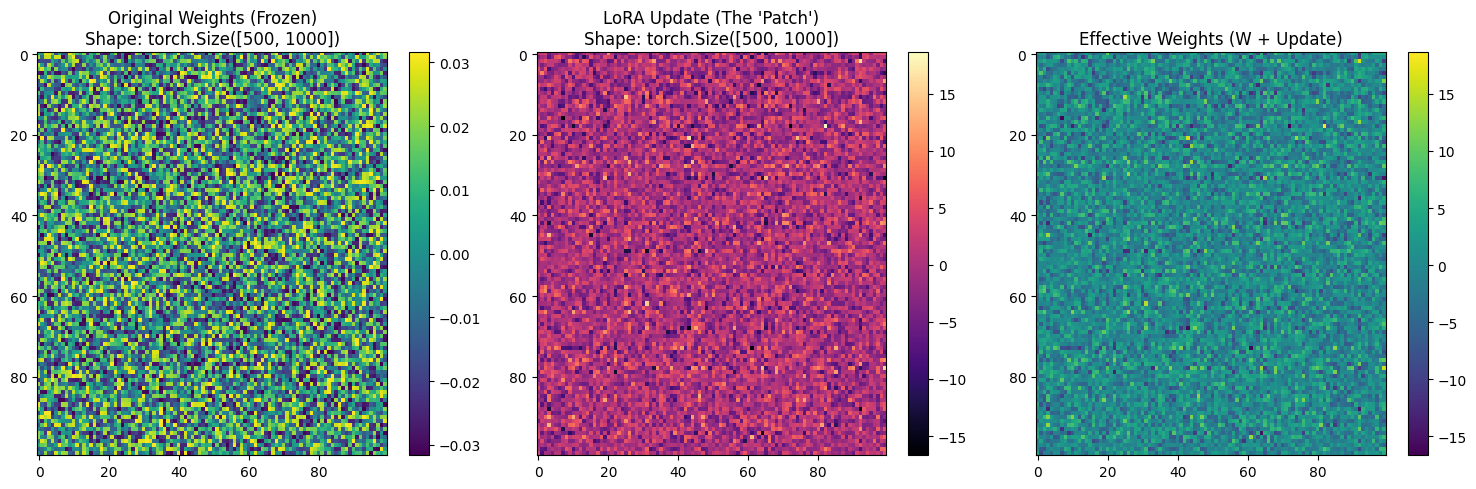

Max value in Original W: 0.0316
Max value in LoRA Update: 23.7114
Notice how the LoRA update is much smaller/subtle compared to the weight


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns # You might need to pip install seaborn, or just use plt.imshow

def visualize_lora_updates(model, layer_name="linear2"):
    # 1. Get the layer
    layer = getattr(model, layer_name)
    
    # 2. Extract Matrices
    # Original Frozen Weight (W)
    W_orig = layer.original_layer.weight.detach().cpu()
    
    # LoRA Matrices (A and B)
    A = layer.lora_A.detach().cpu()
    B = layer.lora_B.detach().cpu()
    scaling = layer.scaling
    
    # Calculate the Update: Delta_W = (A @ B) * scaling
    # A is (Out, Rank) and B is (Rank, In) so A @ B gives (Out, In) to match W.
    delta_W = (A @ B) * scaling

    # 3. Plotting
    plt.figure(figsize=(15, 5))

    # Plot Original Weights
    plt.subplot(1, 3, 1)
    plt.title(f"Original Weights (Frozen)\nShape: {W_orig.shape}")
    # We take a subset (first 100x100) because the full size is too big to see details
    rows, cols = min(100, W_orig.shape[0]), min(100, W_orig.shape[1])
    plt.imshow(W_orig[:rows, :cols], cmap='viridis', aspect='auto')
    plt.colorbar()

    # Plot LoRA Update
    plt.subplot(1, 3, 2)
    plt.title(f"LoRA Update (The 'Patch')\nShape: {delta_W.shape}")
    plt.imshow(delta_W[:rows, :cols], cmap='magma', aspect='auto')
    plt.colorbar()

    # Plot Combined
    plt.subplot(1, 3, 3)
    plt.title("Effective Weights (W + Update)")
    plt.imshow((W_orig + delta_W)[:rows, :cols], cmap='viridis', aspect='auto')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # 4. Numerical Proof
    print(f"Max value in Original W: {torch.max(torch.abs(W_orig)):.4f}")
    print(f"Max value in LoRA Update: {torch.max(torch.abs(delta_W)):.4f}")
    print("Notice how the LoRA update is much smaller/subtle compared to the weight")

visualize_lora_updates(model)

In [76]:
import math
import torch.nn.functional as F

# 1. A Standard Self-Attention Class (Simplified GPT-style)
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, head_dim):
        super().__init__()
        self.head_dim = head_dim
        
        # Standard Linear Layers for Q, K, V
        self.q_proj = nn.Linear(embed_dim, head_dim)
        self.k_proj = nn.Linear(embed_dim, head_dim)
        self.v_proj = nn.Linear(embed_dim, head_dim)

    def forward(self, x):
        # x shape: (Batch, Seq_Len, Embed_Dim)
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        
        # Scaled Dot-Product Attention
        # Attention = softmax(Q @ K.T / sqrt(dim)) @ V
        d_k = K.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output

# 2. Injecting LoRA into Attention
print("\n--- LEVEL 3: LORA IN TRANSFORMERS ---")

# Setup a dummy attention block (e.g., Embed size 768 like GPT-2 base)
embed_dim = 768
head_dim = 768 # simplified for single head
attention_block = SelfAttention(embed_dim, head_dim).to(device)

print("1. Created Standard Attention Block")
print(f"   Original Q Projector Stats: {attention_block.q_proj.weight.shape}")

# FREEZE EVERYTHING FIRST (Standard LoRA Step 1)
for param in attention_block.parameters():
    param.requires_grad = False

# REPLACE Q and V with LoRA Layers (Standard LoRA Step 2)
# We keep K frozen without LoRA (as per original paper preference)
print("2. Injecting LoRA into Q and V projections...")

# Reuse your LoRALayer class from the previous steps
# Rank 8 is common for Transformers
attention_block.q_proj = LoRALayer(attention_block.q_proj, r=8, alpha=16).to(device)
attention_block.v_proj = LoRALayer(attention_block.v_proj, r=8, alpha=16).to(device)

# 3. Verify Trainable Parameters
trainable_params = sum(p.numel() for p in attention_block.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in attention_block.parameters())

print(f"   Total Parameters: {total_params:,}")
print(f"   Trainable Parameters (LoRA): {trainable_params:,}")
print(f"   Percentage to train: {trainable_params/total_params*100:.3f}%")

# 4. Test Forward Pass
dummy_input = torch.randn(1, 10, embed_dim).to(device) # Batch 1, Sequence Length 10
output = attention_block(dummy_input)
print(f"3. Forward pass successful. Output shape: {output.shape}")
print("   The model is now ready to fine-tune on text data!")


--- LEVEL 3: LORA IN TRANSFORMERS ---
1. Created Standard Attention Block
   Original Q Projector Stats: torch.Size([768, 768])
2. Injecting LoRA into Q and V projections...
   Total Parameters: 1,796,352
   Trainable Parameters (LoRA): 24,576
   Percentage to train: 1.368%
3. Forward pass successful. Output shape: torch.Size([1, 10, 768])
   The model is now ready to fine-tune on text data!


In [83]:
print("\n EXPERIMENT: RANK EFFICIENCY (Section 7.2)")

def test_rank_performance(rank_value):
    print(f"\nTesting LoRA with Rank r={rank_value}...")
    
    # 1. Reset Model
    model = RichBoyNet().to(device)
    
    # 2. Inject LoRA with specific Rank
    # Freeze first
    for param in model.parameters():
        param.requires_grad = False
        
    model.linear2 = LoRALayer(model.linear2, r=rank_value, alpha=rank_value).to(device)
    model.linear3 = LoRALayer(model.linear3, r=rank_value, alpha=rank_value).to(device)
    
    # 3. Train on Digit 9 (Same as before)
    # Note: Using a smaller alpha/rank ratio usually stabilizes training
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    
    model.train()
    for epoch in range(1): # Quick test
        for x, y in loader_9:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = nn.CrossEntropyLoss()(output, y)
            loss.backward()
            optimizer.step()
            
    # 4. Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            mask = (y == 9)
            if mask.sum() > 0:
                correct += (predicted[mask] == y[mask]).sum().item()
                total += mask.sum().item()
    
    acc = 100 * correct / total
    print(f"Rank {rank_value} Accuracy on Digit 9: {acc:.2f}%")
    return acc

# Compare Rank 1, 4, and 64
r1 = test_rank_performance(1)
r4 = test_rank_performance(4)
r64 = test_rank_performance(64)


 EXPERIMENT: RANK EFFICIENCY (Section 7.2)

Testing LoRA with Rank r=1...
Rank 1 Accuracy on Digit 9: 76.51%

Testing LoRA with Rank r=4...
Rank 4 Accuracy on Digit 9: 100.00%

Testing LoRA with Rank r=64...
Rank 64 Accuracy on Digit 9: 100.00%


--- Visualizing Top 5 Predictions for Digit '4' ---


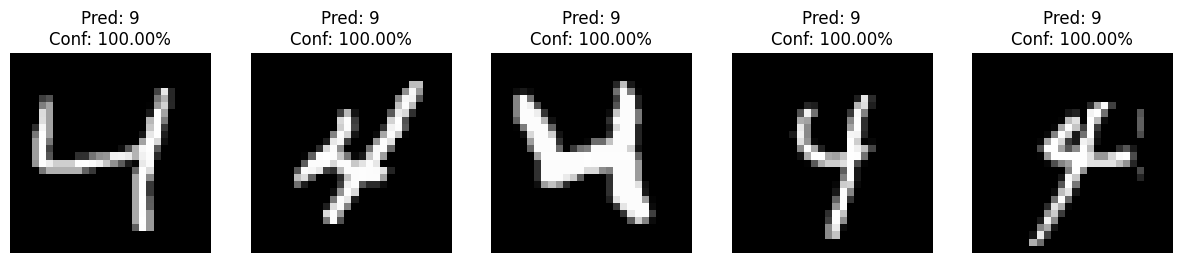

--- Visualizing Top 5 Predictions for Digit '5' ---


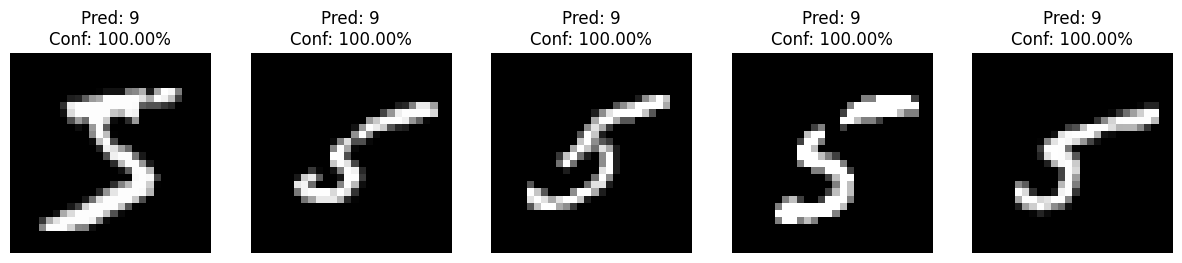

--- Visualizing Top 5 Predictions for Digit '6' ---


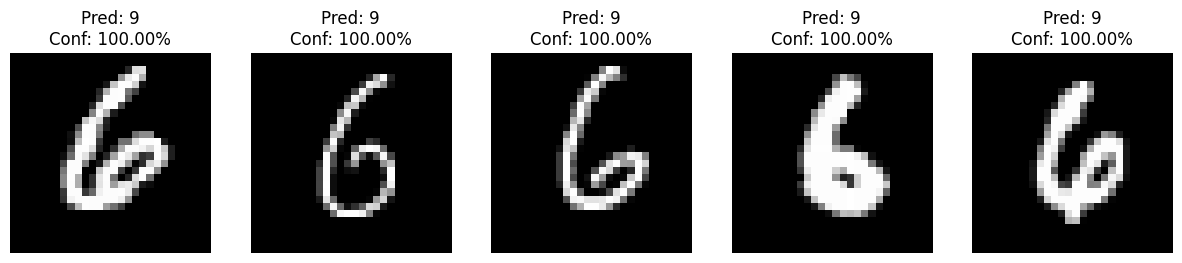

--- Visualizing Top 5 Predictions for Digit '2' ---


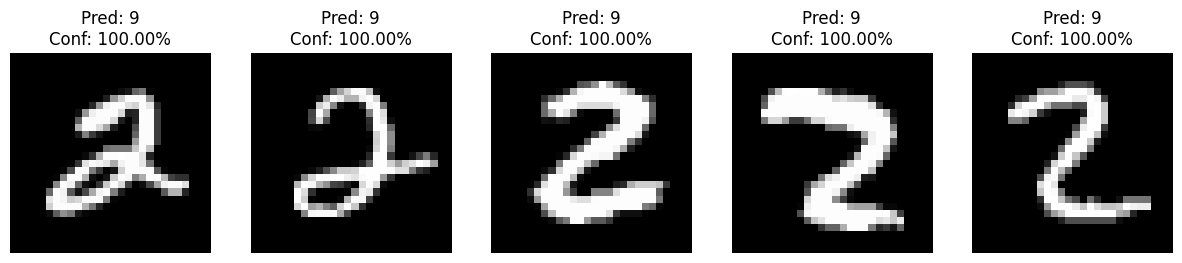

In [88]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_prediction(model, dataset, digit=2, num_samples=5):
    # 1. Get images of the digit '9'
    indices = dataset.targets == digit
    data_9 = dataset.data[indices]
    targets_9 = dataset.targets[indices]
    
    # 2. Setup the plot
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    print(f"--- Visualizing Top {num_samples} Predictions for Digit '{digit}' ---")
    
    # 3. Run predictions
    model.eval()
    with torch.no_grad():
        for i in range(num_samples):
            # Prepare image
            img = data_9[i].float() / 255.0 # Normalize roughly
            img_normalized = (img - 0.1307) / 0.3081 # Apply MNIST normalization
            img_tensor = img_normalized.view(1, 1, 28, 28).to(device)
            
            # Predict
            output = model(img_tensor)
            
            # Get Probability (Confidence)
            probs = F.softmax(output, dim=1)
            prediction = torch.argmax(probs).item()
            confidence = probs[0][prediction].item() * 100
            
            # Plot
            axes[i].imshow(data_9[i], cmap='gray')
            axes[i].set_title(f"Pred: {prediction}\nConf: {confidence:.2f}%")
            axes[i].axis('off')
            
            # Color code the border
            if prediction == digit:
                # Green border for correct
                plt.setp(axes[i].spines.values(), color='green', linewidth=3)
            else:
                # Red border for wrong
                plt.setp(axes[i].spines.values(), color='red', linewidth=3)

    plt.show()

# Run the visualization on your trained model
visualize_prediction(model, train_dataset,digit=4, num_samples=5)
visualize_prediction(model, train_dataset,digit=5, num_samples=5)
visualize_prediction(model, train_dataset,digit=6, num_samples=5)
visualize_prediction(model, train_dataset,digit=2, num_samples=5)